In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, color, morphology
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops
from skimage.draw import rectangle, disk


In [2]:
def show_images(images, titles=None):
    n = len(images)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()


# 2)
2)(*) Representacion por relleno de regiones. Identificar los objetos en una imagen binaria y colorear
cada region detectada. Sugerencia: scikit-image: measure.label, regionprops, label2rgb.

Los distintos algoritmos involucrados cumplen las siguientes funciones:
1) `label()` recorre la imagen y asigna etiquetas diferentes a cada conjunto de píxeles conectados (usando un algoritmo como Union-Find o Flood-Fill).
2) `regionprops()` analiza esos conjuntos etiquetados para extraer características geométricas y estadísticas.
3) `label2rgb()` toma la matriz de etiquetas y le asigna un color diferente a cada etiqueta, lo que permite visualizar los objetos.

El resultado final es una imagen donde cada objeto detectado se muestra con un unico color (segmentacion).


Regiones detectadas: 208
Región 1: área=8962.0, centro=(np.float64(37.25016737335416), np.float64(65.39511269805847))
Región 2: área=164827.0, centro=(np.float64(275.76242363205057), np.float64(328.9617781067422))
Región 3: área=17704.0, centro=(np.float64(114.60957975598735), np.float64(595.6423971983733))
Región 4: área=10.0, centro=(np.float64(13.5), np.float64(746.0))
Región 5: área=227.0, centro=(np.float64(32.519823788546255), np.float64(759.1453744493392))
Región 6: área=394.0, centro=(np.float64(29.14720812182741), np.float64(175.5482233502538))
Región 7: área=146.0, centro=(np.float64(29.65068493150685), np.float64(743.1095890410959))
Región 8: área=1.0, centro=(np.float64(28.0), np.float64(6.0))
Región 9: área=7.0, centro=(np.float64(32.42857142857143), np.float64(3.2857142857142856))
Región 10: área=1.0, centro=(np.float64(32.0), np.float64(11.0))
Región 11: área=23.0, centro=(np.float64(36.56521739130435), np.float64(730.9130434782609))
Región 12: área=2.0, centro=(np.float

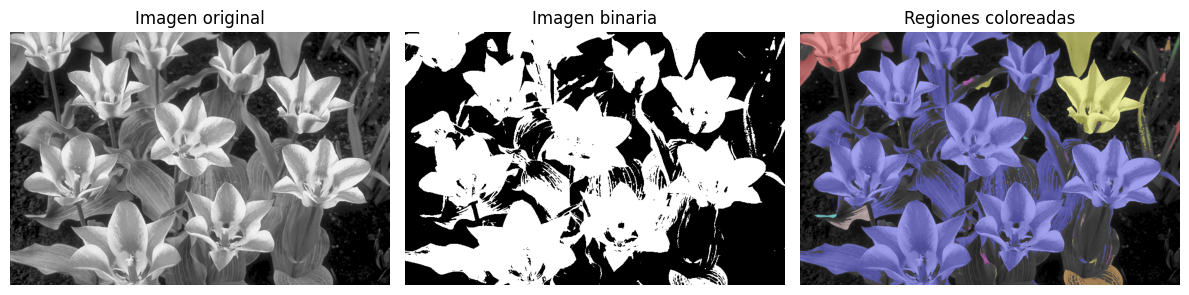

In [6]:
# Cargar imagen en escala de grises
imagen = cv2.imread('tulips.png', cv2.IMREAD_GRAYSCALE)  

# Umbral automático (por ejemplo, Otsu)
umbral = cv2.threshold(imagen, 50, 180, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0]
imagen_binaria = imagen > umbral  # True para fondo claro, False para oscuro

# Etiquetado de componentes conectados
etiquetas = measure.label(imagen_binaria, connectivity=2)
print(f"Regiones detectadas: {etiquetas.max()}")  # No cuenta el fondo

# Convertir etiquetas a colores (colorea cada región con un color diferente)
imagen_coloreada = color.label2rgb(etiquetas, image=imagen, bg_label=0)

# También podemos obtener propiedades de cada región
regiones = measure.regionprops(etiquetas)
for i, region in enumerate(regiones):
    print(f"Región {i+1}: área={region.area}, centro={region.centroid}")

# Mostrar imágenes
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen, cmap='gray')
plt.title("Imagen original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imagen_binaria, cmap='gray')
plt.title("Imagen binaria")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagen_coloreada)
plt.title("Regiones coloreadas")
plt.axis('off')

plt.tight_layout()
plt.show()


# 4)
4)(*) Calculo de propiedades geometricas. Extraer area, perımetro, excentricidad y compacidad de
cada region segmentada. Sugerencia: regionprops de skimage.measure.

Descricion de las propiedades geométricas:

 **Área**: Cantidad de píxeles que forman la región. 
 
 **Perímetro**: Longitud de la frontera del objeto (estimado). 
 
 **Excentricidad**: Relación entre los ejes de la elipse que mejor ajusta la región (0: círculo, 1: línea).
 
 **Compacidad**: Medida de forma: $C = \frac{P^2}{4\pi A}$, idealmente ≈1 para círculos.
 
Basicamente todas estas propiedades nos puede ubicar en datos como el tamaño de los objetos, su forma y como se distribuyen en el espacio.

Excentricidad → Cerca de 0: círculo | Cerca de 1: elipse larga / línea.

Compacidad → Cerca de 1: figura compacta (círculo). Alta compacidad → figura irregular o alargada. 



Región 1:
  Área: 5183.0
  Perímetro: 283.41
  Excentricidad: 0.03
  Compacidad: 1.23
------------------------------
Región 2:
  Área: 4069.0
  Perímetro: 234.89
  Excentricidad: 0.03
  Compacidad: 1.08
------------------------------
Región 3:
  Área: 4081.0
  Perímetro: 235.14
  Excentricidad: 0.09
  Compacidad: 1.08
------------------------------
Región 4:
  Área: 5183.0
  Perímetro: 283.41
  Excentricidad: 0.03
  Compacidad: 1.23
------------------------------
Región 5:
  Área: 4070.0
  Perímetro: 234.89
  Excentricidad: 0.07
  Compacidad: 1.08
------------------------------
Región 6:
  Área: 4082.0
  Perímetro: 235.14
  Excentricidad: 0.10
  Compacidad: 1.08
------------------------------
Región 7:
  Área: 2286.0
  Perímetro: 223.99
  Excentricidad: 0.14
  Compacidad: 1.75
------------------------------
Región 8:
  Área: 2282.0
  Perímetro: 223.79
  Excentricidad: 0.16
  Compacidad: 1.75
------------------------------
Región 9:
  Área: 4089.0
  Perímetro: 235.14
  Excentricidad: 0.

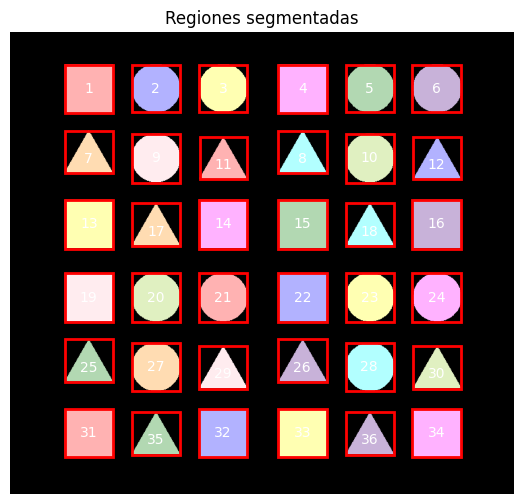

In [10]:
imagen = cv2.imread('shapes.png', cv2.IMREAD_GRAYSCALE)
_, binaria = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)

label_img = label(binaria)
imagen_etiquetada = color.label2rgb(label_img, image=binaria, bg_label=0)

props = regionprops(label_img)

for i, region in enumerate(props):
    area = region.area
    perimetro = region.perimeter
    excentricidad = region.eccentricity
    compacidad = (perimetro ** 2) / (4 * np.pi * area) if area > 0 else 0

    print(f"Región {i + 1}:")
    print(f"  Área: {area}")
    print(f"  Perímetro: {perimetro:.2f}")
    print(f"  Excentricidad: {excentricidad:.2f}")
    print(f"  Compacidad: {compacidad:.2f}")
    print("-" * 30)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(imagen_etiquetada)

for region in props:
    y0, x0 = region.centroid
    minr, minc, maxr, maxc = region.bbox
    rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr,
                         edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(rect)
    ax.text(x0, y0, f"{int(region.label)}", color='white', ha='center', va='center')

plt.title('Regiones segmentadas')
plt.axis('off')
plt.show()


# 6)
6)(*) Descriptores de textura con GLCM. Calcular contraste, correlacion y homogeneidad de regiones
usando matrices de co-ocurrencia. skimage.feature.greycomatrix, greycoprops.

Una GLCM (Matriz de Co-ocurrencia de Niveles de Gris) es una herramienta para analizar la textura de una imagen, cuantificando cómo se relacionan los niveles de gris entre píxeles vecinos.
Cada celda (i,j) de la GLCM indica cuántas veces ocurre una pareja de píxeles donde un píxel tiene valor i y su vecino tiene valor j, bajo cierta dirección y distancia. Gracias a esto podemos captar patrones de textura como rugosidad, homogeneidad, y dirección, al observar cómo se distribuyen las intensidades vecinas. Para esto tenemos 3 descriptores principales:

**Contraste**: Mide la diferencia local de los niveles de gris. Un valor alto indica una textura 'rugosa'.

**Correlación**: Mide la linealidad de la relación entre los niveles de gris de los píxeles vecinos. Un valor alto indica una textura homogénea y repetitiva.

**Homogeneidad**: Mide la cercanía de la distribución de los elementos a la diagonal de la GLCM. Un valor alto indica una textura muy uniforme.



Contraste:
[[156.73700224 229.77816315 153.39982103 287.75068691]]
Correlación:
[[0.96655226 0.95100431 0.96748594 0.93864191]]
Homogeneidad:
[[0.21780395 0.19163367 0.26018306 0.18837595]]


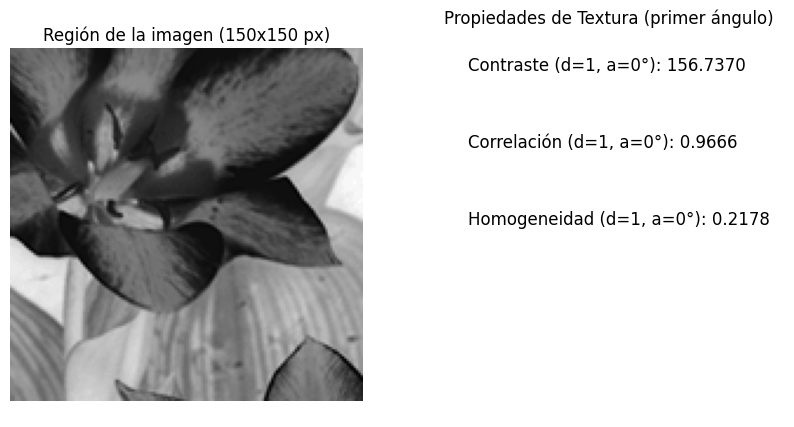


Valores promediados (para todas las orientaciones):
Contraste promedio: 206.9164
Correlación promedio: 0.9559
Homogeneidad promedio: 0.2145


In [11]:
imagen = cv2.imread('tulips.png', cv2.IMREAD_GRAYSCALE)

# Si la imagen es flotante (como la de rgb2gray), es necesario escalarla y convertirla a uint8.
image_uint8 = (imagen * 255).astype(np.uint8)

# Para demostrar con una región más pequeña, podemos cortar un parche
# Esto es útil si quieres analizar regiones específicas de la imagen.
region_size = 150
center_x, center_y = imagen.shape[1] // 2, imagen.shape[0] // 2
region = image_uint8[center_y - region_size//2 : center_y + region_size//2,
                     center_x - region_size//2 : center_x + region_size//2]

# 2. Definir los parámetros para la GLCM
distances = [1] # Analizamos píxeles adyacentes
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4] # En 0, 45, 90 y 135 grados
levels = 256 # Para una imagen uint8

# 3. Calcular la GLCM para la región
glcm = graycomatrix(region,
                    distances=distances,
                    angles=angles,
                    levels=levels,
                    symmetric=True,  # Generalmente True para análisis de textura
                    normed=True)     # Normalizado para obtener probabilidades

# La forma de 'glcm' será (levels, levels, len(distances), len(angles))

# 4. Extraer las propiedades de textura
contrast = graycoprops(glcm, 'contrast')
print(f"Contraste:\n{contrast}")

correlation = graycoprops(glcm, 'correlation')
print(f"Correlación:\n{correlation}")

homogeneity = graycoprops(glcm, 'homogeneity')
print(f"Homogeneidad:\n{homogeneity}")

# Visualización de la región y algunos resultados
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(region, cmap='gray')
plt.title(f'Región de la imagen ({region.shape[0]}x{region.shape[1]} px)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.9, f"Contraste (d=1, a=0°): {contrast[0, 0]:.4f}", fontsize=12)
plt.text(0.1, 0.7, f"Correlación (d=1, a=0°): {correlation[0, 0]:.4f}", fontsize=12)
plt.text(0.1, 0.5, f"Homogeneidad (d=1, a=0°): {homogeneity[0, 0]:.4f}", fontsize=12)
plt.title('Propiedades de Textura (primer ángulo)')
plt.axis('off')

plt.show()

# Puedes promediar los valores de las diferentes orientaciones si necesitas un único valor por propiedad
mean_contrast = np.mean(contrast)
mean_correlation = np.mean(correlation)
mean_homogeneity = np.mean(homogeneity)

print(f"\nValores promediados (para todas las orientaciones):")
print(f"Contraste promedio: {mean_contrast:.4f}")
print(f"Correlación promedio: {mean_correlation:.4f}")
print(f"Homogeneidad promedio: {mean_homogeneity:.4f}")

# 8)
8)(*) Relacion espacial entre regiones. Determinar si las regiones estan adyacentes o si una esta contenida en otra. skimage.measure.regionprops + analisis de coordenadas / bounding boxes.

--- Relaciones de Contención ---
Región 1 NO está contenida en Región 2.
Región 2 NO está contenida en Región 1.

--- Relaciones de Adyacencia ---
Región 3 es adyacente a Región 2.
Región 3 NO es adyacente a Región 4.


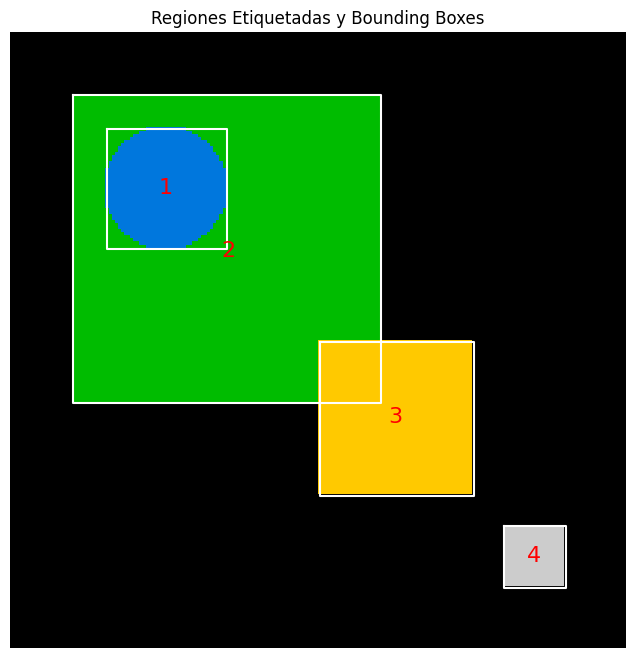

In [17]:
def create_rectangle_mask(shape, r_start, c_start, height, width):

    mask = np.zeros(shape, dtype=bool)
    r_end = min(r_start + height, shape[0])
    c_end = min(c_start + width, shape[1])
    mask[r_start:r_end, c_start:c_end] = True
    return mask

def is_bbox_contained(bbox_inner, bbox_outer):
    min_r_inner, min_c_inner, max_r_inner, max_c_inner = bbox_inner
    min_r_outer, min_c_outer, max_r_outer, max_c_outer = bbox_outer

    return (min_r_outer <= min_r_inner and
            max_r_inner <= max_r_outer and
            min_c_outer <= min_c_inner and
            max_c_inner <= max_c_outer)

def is_region_contained(prop_inner, prop_outer, labeled_img):
    # Primero, un chequeo rápido con bounding boxes
    if not is_bbox_contained(prop_inner.bbox, prop_outer.bbox):
        return False
    # Creamos una máscara para la región exterior
    mask_outer = (labeled_img == prop_outer.label)

    for r, c in prop_inner.coords:
        if not mask_outer[r, c]:
            return False # Un píxel de la región interna está fuera de la externa
    return True # Todos los píxeles internos están dentro de la región externa

def are_adjacent(prop1, prop2, labeled_img, connectivity=1):
    # Crear máscaras binarias para cada región
    mask1 = (labeled_img == prop1.label)
    mask2 = (labeled_img == prop2.label)

    # Definimos el elemento estructurante (footprint) basado en la conectividad
    if connectivity == 1: # 4-conectividad (cruz)
        selem =  morphology.star(1) # 'star' crea una cruz para radio 1
    else: # 8-conectividad (cuadrado 3x3)
        selem = morphology.square(3) # Un cuadrado de 3x3

    # Dilatamos la máscara de la primera región
    dilated_mask1 = morphology.binary_dilation(mask1, footprint=selem)

    # Dilatar la máscara de una región y restar la propia máscara para obtener solo los vecinos.
    dilated_mask1_only_border = dilated_mask1 & ~mask1
    return np.any(dilated_mask1_only_border & mask2)

imagen_shape = (200, 200)

# Inicializar la imagen etiquetada con ceros
labeled_image = np.zeros(imagen_shape, dtype=int)

# Región 2: Un cuadrado más grande (etiqueta 2)
rect2_mask = create_rectangle_mask(imagen_shape, 20, 20, 100, 100)
labeled_image[rect2_mask] = 2

# Región 1: Un círculo contenido en el cuadrado (etiqueta 1)
rr_disk1, cc_disk1 = disk((50, 50), 20, shape=imagen_shape)
labeled_image[rr_disk1, cc_disk1] = 1

# Región 3: Un cuadrado adyacente (etiqueta 3)
rect3_mask = create_rectangle_mask(imagen_shape, 100, 100, 50, 50)
labeled_image[rect3_mask] = 3

# Región 4: Un cuadrado cercano pero no adyacente (etiqueta 4)
rect4_mask = create_rectangle_mask(imagen_shape, 160, 160, 20, 20)
labeled_image[rect4_mask] = 4

# 2. Obtener las propiedades de las regiones
props = measure.regionprops(labeled_image)
props_dict = {prop.label: prop for prop in props}

# 3. Realizar las comprobaciones
print("--- Relaciones de Contención ---")
# ¿Región 1 contenida en Región 2?
if 1 in props_dict and 2 in props_dict:
    prop1 = props_dict[1]
    prop2 = props_dict[2]
    if is_region_contained(prop1, prop2, labeled_image):
        print(f"Región {prop1.label} está contenida en Región {prop2.label}.")
    else:
        print(f"Región {prop1.label} NO está contenida en Región {prop2.label}.")
else:
    print("Regiones 1 y/o 2 no encontradas.")

# ¿Región 3 contenida en Región 2?
if 3 in props_dict and 2 in props_dict:
    prop3 = props_dict[2]
    prop2 = props_dict[1]
    if is_region_contained(prop3, prop2, labeled_image):
        print(f"Región {prop3.label} está contenida en Región {prop2.label}.")
    else:
        print(f"Región {prop3.label} NO está contenida en Región {prop2.label}.")


print("\n--- Relaciones de Adyacencia ---")
# ¿Región 2 adyacente a Región 3?
if 2 in props_dict and 3 in props_dict:
    prop2 = props_dict[3]
    prop3 = props_dict[2]
    if are_adjacent(prop2, prop3, labeled_image):
        print(f"Región {prop2.label} es adyacente a Región {prop3.label}.")
    else:
        print(f"Región {prop2.label} NO es adyacente a Región {prop3.label}.")
else:
    print("Regiones 2 y/o 3 no encontradas.")
# ¿Región 3 adyacente a Región 4?
if 3 in props_dict and 4 in props_dict:
    prop3 = props_dict[3]
    prop4 = props_dict[4]
    if are_adjacent(prop3, prop4, labeled_image):
        print(f"Región {prop3.label} es adyacente a Región {prop4.label}.")
    else:
        print(f"Región {prop3.label} NO es adyacente a Región {prop4.label}.")
else:
    print("Regiones 3 y/o 4 no encontradas.")


# 4. Visualización
plt.figure(figsize=(8, 8))
plt.imshow(labeled_image, cmap='nipy_spectral', interpolation='nearest')
for prop in props:
    min_r, min_c, max_r, max_c = prop.bbox
    bx = (min_c, max_c, max_c, min_c, min_c)
    by = (min_r, min_r, max_r, max_r, min_r)
    plt.plot(bx, by, '-w', linewidth=1.5) # Dibujar bounding box
    plt.text(prop.centroid[1], prop.centroid[0], str(prop.label), color='red',
             fontsize=16, ha='center', va='center')
plt.title('Regiones Etiquetadas y Bounding Boxes')
plt.axis('off')
plt.show()
